In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("swiggy_data.csv")
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [4]:
conn=sqlite3.connect("swigg.db")
df.to_sql("restaurants",conn, if_exists="replace",
index=False)

8680

In [5]:
city_df = pd.read_sql_query("""
SELECT City, COUNT(*) as total_restaurants
FROM restaurants
GROUP BY City
ORDER BY total_restaurants DESC
LIMIT 10
""", conn)

city_df

,City,total_restaurants
0,Kolkata,1346
1,Mumbai,1277
2,Chennai,1106
3,Pune,1090
4,Hyderabad,1075
5,Bangalore,946
6,Ahmedabad,717
7,Delhi,611
8,Surat,512


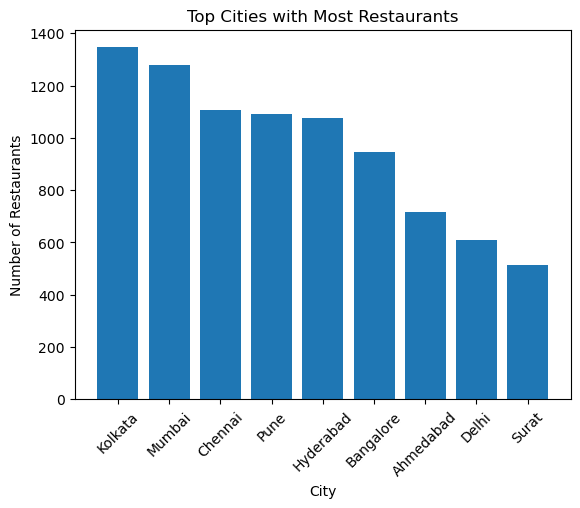

In [7]:
plt.figure()

plt.bar(city_df["City"], city_df["total_restaurants"])

plt.title("Top Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

In [ ]:
Insights:

Kolkata and Mumbai have the highest number of restaurants on Swiggy,
indicating strong food delivery demand in metro cities.

In [8]:
rating_df = pd.read_sql_query("""
SELECT Restaurant, City, `Avg ratings`
FROM restaurants
ORDER BY `Avg ratings` DESC
LIMIT 10
""", conn)

rating_df

,Restaurant,City,Avg ratings
0,Diamond Market Pizza Jp,Mumbai,5.0
1,Get In My Belly,Mumbai,5.0
2,The Asian Pavilion,Mumbai,5.0
3,Cafe Kokomo,Mumbai,5.0
4,Papacream,Pune,5.0
5,Wallonia Waffle Co.,Hyderabad,5.0
6,Splurge - Thickshakes And Milkshakes,Hyderabad,5.0
7,The Liege Waffles,Hyderabad,5.0
8,Nivala Apka Apna,Mumbai,5.0
9,Tricky Shakes,Bangalore,5.0


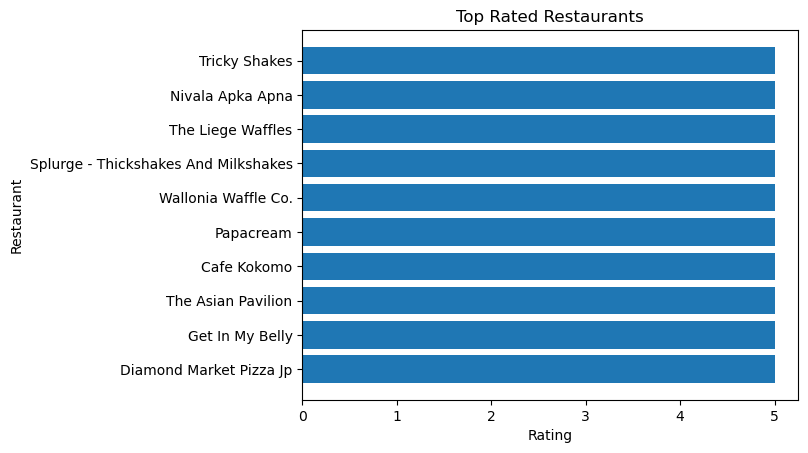

In [9]:
plt.figure()

plt.barh(rating_df["Restaurant"], rating_df["Avg ratings"])

plt.title("Top Rated Restaurants")
plt.xlabel("Rating")
plt.ylabel("Restaurant")

plt.show()

In [ ]:
Insights:

Several restaurants maintain ratings close to 5,
showing strong customer satisfaction.

In [10]:
price_df = pd.read_sql_query("""
SELECT Price
FROM restaurants
""", conn)

price_df

,Price
0,300.0
1,300.0
2,650.0
3,250.0
4,350.0
...,...
8675,500.0
8676,200.0
8677,150.0
8678,150.0


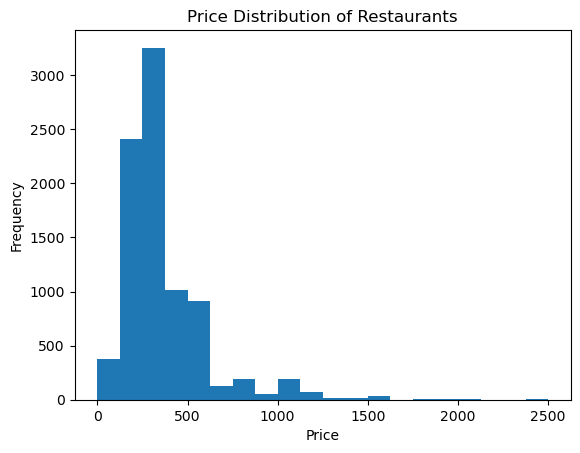

In [12]:
plt.figure()

plt.hist(price_df["Price"], bins=20)

plt.title("Price Distribution of Restaurants")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
Insights:

Most restaurants fall within the ₹200–₹500 price range,
showing that mid-range pricing dominates food delivery platforms.

In [16]:
avg_price_df = pd.read_sql_query("""
SELECT City, AVG(Price) as avg_price
FROM restaurants
GROUP BY City
ORDER BY avg_price DESC
LIMIT 10
""", conn)

avg_price_df

,City,avg_price
0,Mumbai,393.794832
1,Bangalore,382.524313
2,Kolkata,362.294205
3,Chennai,356.247740
4,Pune,353.763303
5,Delhi,333.301146
6,Ahmedabad,318.128312
7,Hyderabad,299.926512
8,Surat,270.171875


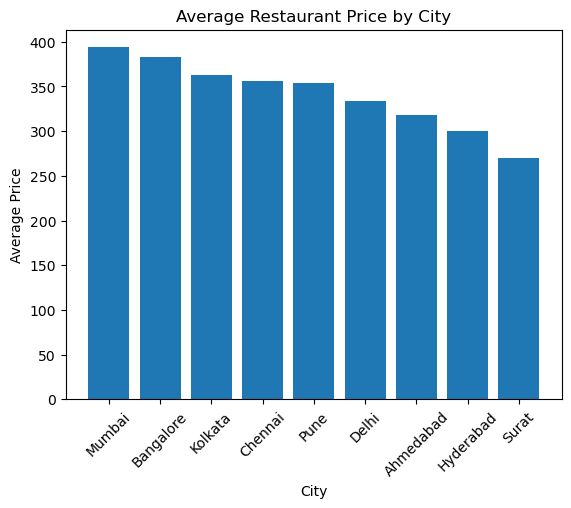

In [17]:
plt.figure()

plt.bar(avg_price_df["City"], avg_price_df["avg_price"])

plt.title("Average Restaurant Price by City")
plt.xlabel("City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

In [ ]:
Insights:

Some cities show higher average prices,
which may indicate premium restaurants or higher living costs.